In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../Airlinedataset.csv")

features = [
    "days_to_departure",
    "seats_remaining",
    "historical_demand",
    "competitor_price",
    "booking_velocity",
    "is_weekend",
    "flight_capacity"
]

target = "ticket_price"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

In [3]:
print("Residual Mean:", residuals.mean())
print("Residual Std:", residuals.std())
print("Residual Min:", residuals.min())
print("Residual Max:", residuals.max())

Residual Mean: 1.6316761833913551
Residual Std: 278.87417408068643
Residual Min: -832.107654820169
Residual Max: 739.2190364405778


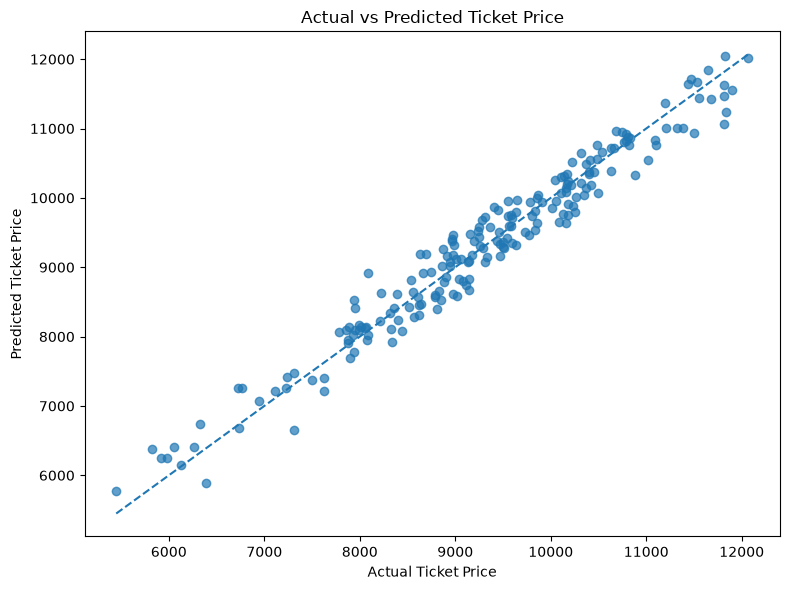

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Ticket Price")
plt.ylabel("Predicted Ticket Price")
plt.title("Actual vs Predicted Ticket Price")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

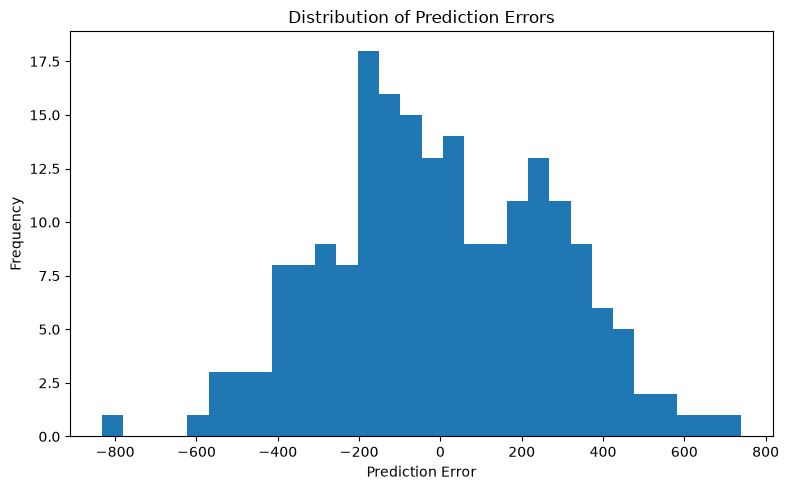

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

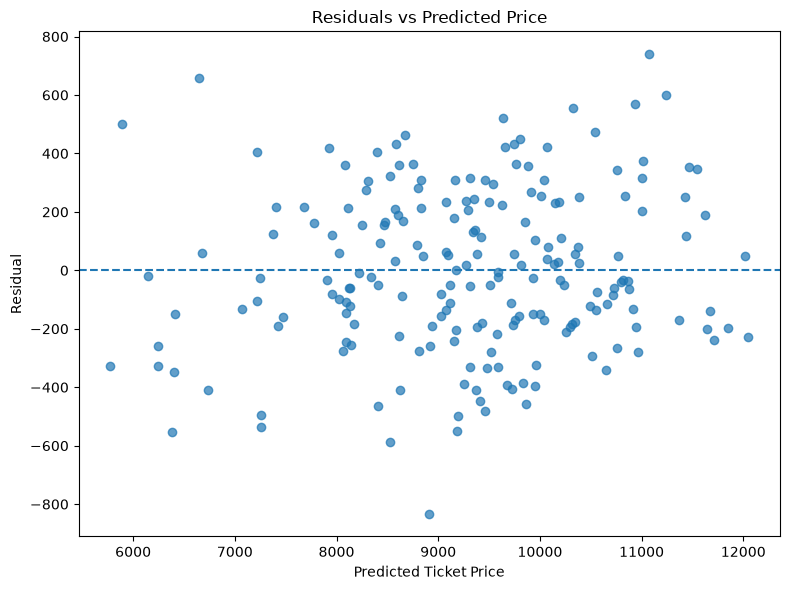

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Ticket Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price")

plt.tight_layout()
plt.show()

In [7]:
df["linear_price_estimate"] = (
    model.intercept_
    + sum(
        model.coef_[i] * df[feature]
        for i, feature in enumerate(features)
    )
)

reconstruction_error = (
    df["ticket_price"] - df["linear_price_estimate"]
).abs()

print("Mean reconstruction error:",
      reconstruction_error.mean())

print("Maximum reconstruction error:",
      reconstruction_error.max())

Mean reconstruction error: 224.54461201629974
Maximum reconstruction error: 915.4655084328369


In [8]:
print("Residual Mean:", residuals.mean())
print("Residual Std:", residuals.std())
print("Residual Min:", residuals.min())
print("Residual Max:", residuals.max())

Residual Mean: 1.6316761833913551
Residual Std: 278.87417408068643
Residual Min: -832.107654820169
Residual Max: 739.2190364405778


## Model Diagnostic Findings

The baseline Linear Regression model achieved an R² of 0.9585 with an MAE of 228.29.

Residual analysis showed that:

- The mean residual was close to zero (1.63), indicating little overall prediction bias.
- Residuals were broadly distributed around zero without a strong obvious curved pattern.
- Individual prediction errors remained substantial, with residuals ranging from approximately -832 to +739.
- The prediction-error distribution was centered near zero but showed noticeable spread rather than behaving like negligible noise.
- The mean absolute reconstruction error across the dataset was approximately 224.54.

These results indicate that the model captures most of the systematic variation in ticket prices, while some pricing variation remains unexplained.

The high R² should therefore be interpreted as strong predictive performance on this dataset rather than evidence of a complete real-world airline pricing mechanism.